<a href="https://colab.research.google.com/github/lcn781/M10---Descritiva-II/blob/main/Profissa%CC%83o_Cientista_de_Dados_M10_Pratique_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Módulo 10 tarefa 2

Considere a mesma base de dados utilizada na tarefa 1 ```previsao_de_renda.csv```.

1) Com o que você viu em aula, faça uma análise das variáveis qualitativas (posse de imóvel e posse de veículo) para verificar se são boas preditoras de *renda*. Alguma delas parece discriminar *renda* de forma estatisticamente significante?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

df = pd.read_csv('previsao_de_renda.csv')
df.head()

,Unnamed: 0,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,mau,renda
0,0,2015-01-01,8682,F,False,True,1,Assalariado,Secundário,Casado,Casa,36,3.575342,3.0,False,3369.24
1,1,2015-01-01,12830,M,True,True,0,Empresário,Secundário,Casado,Casa,42,0.860274,2.0,False,6096.14
2,2,2015-01-01,2885,M,True,True,2,Assalariado,Superior completo,Casado,Casa,31,8.065753,4.0,False,5658.98
3,3,2015-01-01,16168,F,True,False,0,Empresário,Secundário,Casado,Casa,50,1.208219,2.0,False,7246.69
4,4,2015-01-01,12438,M,False,False,0,Assalariado,Secundário,Casado,Casa,52,13.873973,2.0,False,4017.37


### Análise da variável `posse_de_imovel`

In [6]:
df['posse_de_imovel'].value_counts()

,count
posse_de_imovel,
True,10082
False,4918


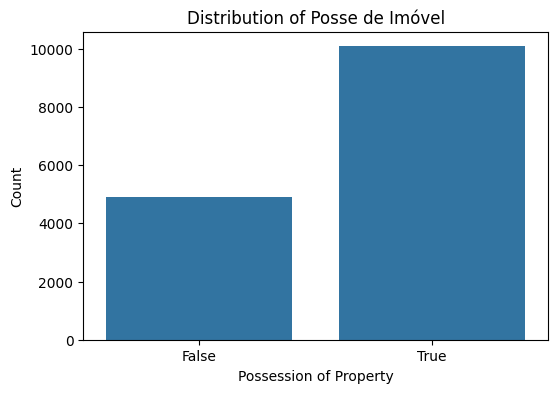

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x='posse_de_imovel', data=df)
plt.title('Distribution of Posse de Imóvel')
plt.xlabel('Possession of Property')
plt.ylabel('Count')
plt.show()

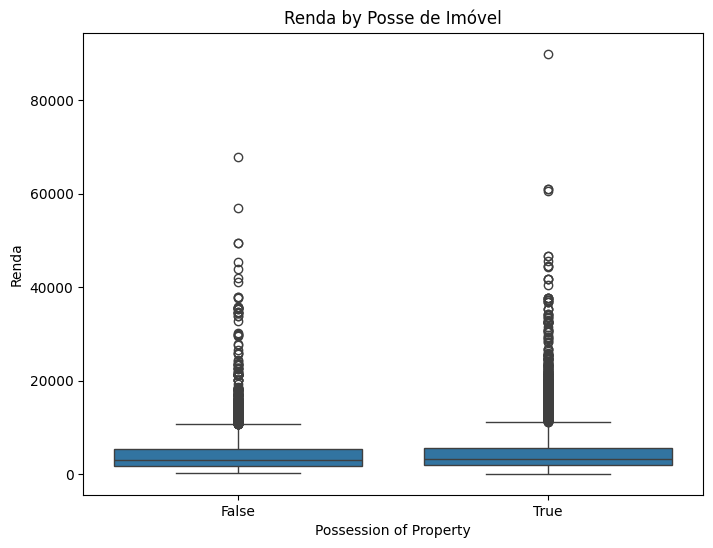

In [9]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='posse_de_imovel', y='renda', data=df)
plt.title('Renda by Posse de Imóvel')
plt.xlabel('Possession of Property')
plt.ylabel('Renda')
plt.show()

In [11]:
mean_renda_by_posse_imovel = df.groupby('posse_de_imovel')['renda'].mean().round(2)
display(mean_renda_by_posse_imovel)

,renda
posse_de_imovel,
False,4426.97
True,4721.05


### Análise da variável `posse_de_veiculo`

In [13]:
df['posse_de_veiculo'].value_counts()

,count
posse_de_veiculo,
False,9167
True,5833


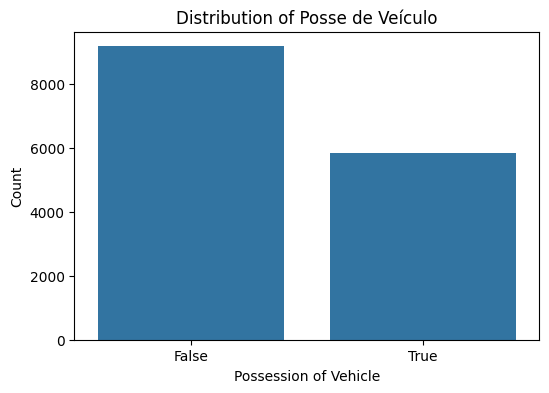

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(x='posse_de_veiculo', data=df)
plt.title('Distribution of Posse de Veículo')
plt.xlabel('Possession of Vehicle')
plt.ylabel('Count')
plt.show()

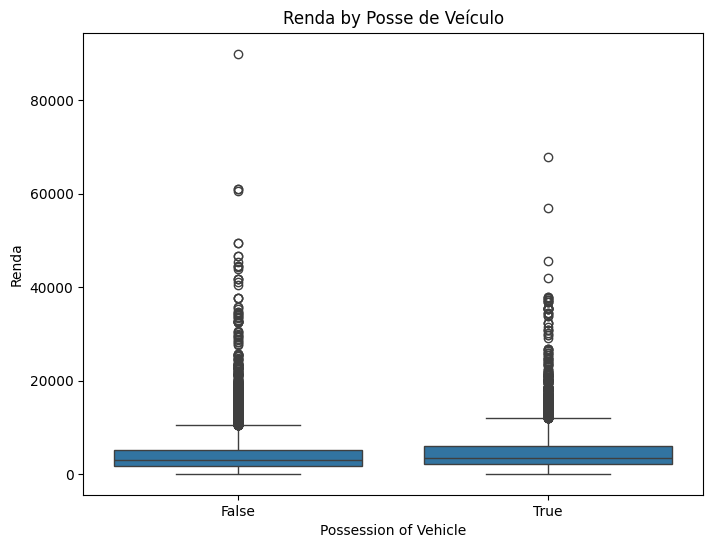

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='posse_de_veiculo', y='renda', data=df)
plt.title('Renda by Posse de Veículo')
plt.xlabel('Possession of Vehicle')
plt.ylabel('Renda')
plt.show()

In [16]:
mean_renda_by_posse_veiculo = df.groupby('posse_de_veiculo')['renda'].mean().round(2)
display(mean_renda_by_posse_veiculo)

,renda
posse_de_veiculo,
False,4390.51
True,4992.58


### Análise Estatística: ANOVA para Posse de Imóvel e Renda

In [26]:
from scipy.stats import f_oneway

# Group renda by 'posse_de_imovel'
group_imovel_true = df[df['posse_de_imovel'] == True]['renda']
group_imovel_false = df[df['posse_de_imovel'] == False]['renda']

# Perform ANOVA test
f_statistic_imovel, p_value_imovel = f_oneway(group_imovel_true, group_imovel_false)

print(f'ANOVA F-statistic for posse_de_imovel: {f_statistic_imovel:.2f}')
print(f'ANOVA p-value for posse_de_imovel: {p_value_imovel:.4f}')

if p_value_imovel < 0.05:
    print("\nThere is a statistically significant difference in 'renda' based on 'posse_de_imovel'.")
else:
    print("\nThere is no statistically significant difference in 'renda' based on 'posse_de_imovel'.")

ANOVA F-statistic for posse_de_imovel: 13.36
ANOVA p-value for posse_de_imovel: 0.0003

There is a statistically significant difference in 'renda' based on 'posse_de_imovel'.


### Análise Estatística: ANOVA para Posse de Veículo e Renda

In [27]:
# Group renda by 'posse_de_veiculo'
group_veiculo_true = df[df['posse_de_veiculo'] == True]['renda']
group_veiculo_false = df[df['posse_de_veiculo'] == False]['renda']

# Perform ANOVA test
f_statistic_veiculo, p_value_veiculo = f_oneway(group_veiculo_true, group_veiculo_false)

print(f'ANOVA F-statistic for posse_de_veiculo: {f_statistic_veiculo:.2f}')
print(f'ANOVA p-value for posse_de_veiculo: {p_value_veiculo:.4f}')

if p_value_veiculo < 0.05:
    print("\nThere is a statistically significant difference in 'renda' based on 'posse_de_veiculo'.")
else:
    print("\nThere is no statistically significant difference in 'renda' based on 'posse_de_veiculo'.")

ANOVA F-statistic for posse_de_veiculo: 60.56
ANOVA p-value for posse_de_veiculo: 0.0000

There is a statistically significant difference in 'renda' based on 'posse_de_veiculo'.


# CONCLUSÃO


Sim. Uma análise das variáveis qualitativas indica que ambas variáveis ('posse_de_imovel' e 'posse_de_veiculo') estão positivamente correlacionadas com a 'renda'.
Quando a presença delas é combinada, parece amplificar a renda média. Indivíduos que possuem imóvel ou veículo, tendem a apresentar uma média de renda maior.